## Load a model and predict using a specific image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Probability Unbleached: 0.11602135002613068
Probability Bleached: 0.8839786499738693
Predicted class index: 0
Predicted class: Bleached


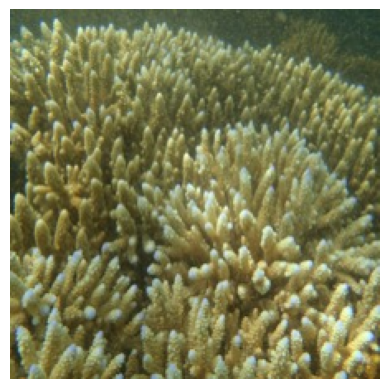

In [ ]:
import tensorflow as tf
import os
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import io

# Define paths
test_data_dir = '/Users/et/code/Lucia-Cordero/ReefSight-Project/raw_data/image_data/train_validation_test/test'
model_path = '/Users/et/code/Lucia-Cordero/ReefSight-Project/models/VGG16_image_model.keras'
img_path = os.path.join(test_data_dir, 'Bleached', '16100757799_d478793c8a_o.jpg')  # Using os.path.join for better compatibility
img_path = os.path.join(test_data_dir, 'Unbleached', '5.png')  # Using os.path.join for better compatibility
class_names = ['Bleached', 'Unbleached']

# Load model
model_loaded = tf.keras.models.load_model(model_path)

#img = image.load_img(img_path)
with open(img_path,'rb') as file:
    img = file.read()

img = Image.open(io.BytesIO(img))

img = img.convert('RGB')
img = img.resize((224, 224))
img_array = image.img_to_array(img)
img_array = img_array.reshape((-1, 224, 224, 3))

# Make prediction
predictions = model_loaded.predict(img_array)
print(f"Probability Unbleached: {predictions[0][0]}")
print(f"Probability Bleached: {1 - predictions[0][0]}")

predicted_class = (predictions[0][0] >= 0.5).astype("int32")
print(f"Predicted class index: {predicted_class}")

predicted_label = class_names[predicted_class]
print(f"Predicted class: {predicted_label}")

# Visualize the image
plt.imshow(img)
plt.axis('off')
plt.show()